## Exercise 6

#### AI Declaration
ChatGPT was used to do this exercise to plot the graph 

In [4]:
#importing statements
import numpy as np
import matplotlib.pyplot as plt

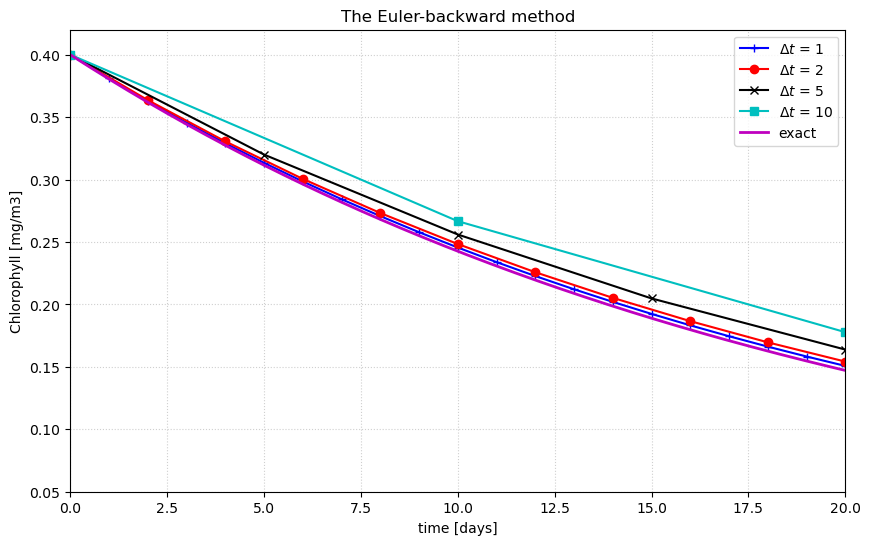

In [3]:
# Fixed parameters
t0 = 0
tn = 20
kappa = 0.05  # day^-1
C0 = 0.4      # mg chl m^-3

# Different time steps to test (matching the original slide)
dt_values = [1, 2, 5, 10]
colors = ['b', 'r', 'k', 'c']
markers = ['+', 'o', 'x', 's']

plt.figure(figsize=(10, 6))

# Loop through each dt value to compute and plot
for idx, dt in enumerate(dt_values):
    # Compute total number of steps
    Ntot = int(np.floor((tn - t0) / dt) + 1)
    
    # Initializations
    C = np.zeros(Ntot)
    t = np.zeros(Ntot)
    t[0] = t0
    C[0] = C0
    
    # Start the Euler-backward loop
    for n in range(0, Ntot - 1):
        t[n+1] = t[n] + dt
        # Euler-backward algebraic update step:
        C[n+1] = C[n] / (1 + kappa * dt)
        
    # Plot current dt result
    plt.plot(t, C, color=colors[idx], linestyle='-', marker=markers[idx], 
             label=f'$\Delta t$ = {dt}')

# Plot Exact Analytical Solution
t_exact = np.linspace(t0, tn, 200)
C_exact = C0 * np.exp(-kappa * t_exact)
plt.plot(t_exact, C_exact, color='m', linestyle='-', linewidth=2, label='exact')

# Formatting the plot to match your slide exactly
plt.xlabel('time [days]')
plt.ylabel('Chlorophyll [mg/m3]')
plt.title('The Euler-backward method')
plt.xlim(0, tn)
plt.ylim(0.05, 0.42)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(loc='upper right')
plt.show()

The Euler-backward method is unconditionally stable even with very large time steps (Δt=10)